# 02.4 — Does the Topological Auto-Encoder actually work? A Swiss roll sanity check

Phase 02.4 is testing whether a Topological Auto-Encoder (Moor, Horn, Rieck, Borgwardt, ICML
2020, arXiv:1906.00722) recovers usable structure from the PU embedding manifold. A FAIL on
that data has two possible causes: the data has no topological structure the model can
capture, or the implementation is broken. Only a manifold whose answer is known in advance
separates them.

The Swiss roll is a 2-dimensional surface curled into 3-dimensional space — the standard test
case. A faithful implementation, trained at latent dimension 2, should reconstruct it almost
exactly and preserve its persistence structure; a model that collapsed or short-circuited will
visibly fail to.

Nothing here is pre-registered, cached, or gated. It trains from scratch and runs in under two
minutes.

## §1. Setup

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_swiss_roll

from pu_manifold import cae
from pu_manifold import topoae

SEED = 20260806
N_POINTS = 3000
LATENT_DIM = 2         # the Swiss roll's true intrinsic dimension
HIDDEN = (64, 64, 64)
MAX_EPOCHS = 150

# The lambda a separate sweep runner selected on this same Swiss roll fixture, under a
# selection rule written down before any lambda was measured (see the phase's plan summary).
LAMBDA_TOPO = 0.1

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"topoae module: {topoae.__file__}")

torch 2.13.0+cpu  numpy 2.5.1
topoae module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/topoae.py


## §2. The Swiss roll

3,000 noiseless points, generated with the exact call and constants the separate lambda-sweep
runner used to select `LAMBDA_TOPO` above — same generator, same seed, same split.
Coordinates are centred and divided by a single global standard deviation — one scalar, so the
shape is preserved exactly and only the overall size changes.

The colour is the roll's own arc-length parameter `t`: in every plot below, colour bands
staying in order means the surface stayed in order.

X (3000, 3)  train 2400  holdout 600


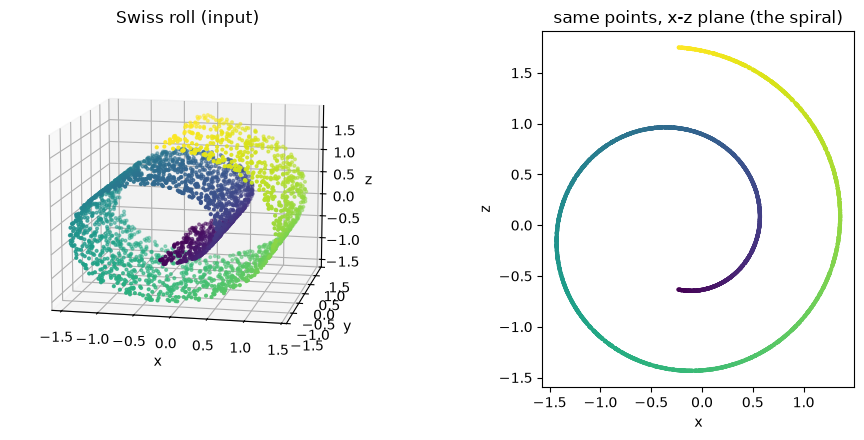

In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=SEED)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std()

rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
n_train = int(0.8 * N_POINTS)
train_idx, holdout_idx = perm[:n_train], perm[n_train:]

x_all = torch.tensor(X, dtype=torch.float32)
x_train = x_all[train_idx]
x_holdout = x_all[holdout_idx]

print(f"X {X.shape}  train {len(train_idx)}  holdout {len(holdout_idx)}")

VIEW = dict(elev=12, azim=-78)  # looks along the roll's extrusion axis, so the spiral shows

fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW)
ax.set_title("Swiss roll (input)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("same points, x-z plane (the spiral)")
ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## §3. Fit the Topological Auto-Encoder

Same `topoae.train_topoae` Phase 02.4 will use on the PU data, only smaller: ambient dimension
3 instead of 768, latent dimension 2, three hidden layers of 64. A matched
`cae.PlainAutoEncoder` baseline is trained under the identical protocol (same width, depth,
batch size, epochs, learning rate, weight decay) at the same 2-D bottleneck — the comparison
`CLAUDE.md` mandates.

TopoAE   epochs_run=150  wallclock_s=63.2


Plain AE epochs_run=150  wallclock_s=10.7
total training wallclock: 75.2s


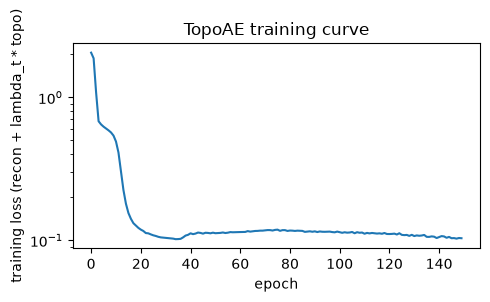

In [3]:
CFG_COMMON = dict(lr=3e-4, weight_decay=1e-4, batch=64, max_epochs=MAX_EPOCHS)

torch.manual_seed(SEED)
model = cae.PlainAutoEncoder(3, LATENT_DIM, hidden=HIDDEN, activation="silu")
topoae_cfg = dict(seed=SEED, lambda_topo=LAMBDA_TOPO, warmup_frac=0.25, ramp_frac=0.25, **CFG_COMMON)
t0 = time.time()
fit = topoae.train_topoae(model, x_train, topoae_cfg)
model.eval()
print(f"TopoAE   epochs_run={fit['epochs_run']}  wallclock_s={fit['wallclock_s']:.1f}")

torch.manual_seed(SEED)
plain = cae.PlainAutoEncoder(3, LATENT_DIM, hidden=HIDDEN, activation="silu")
plain_cfg = dict(seed=SEED, **CFG_COMMON)
plain_fit = cae.train_plain_ae(plain, x_train, plain_cfg)
plain.eval()
print(f"Plain AE epochs_run={plain_fit['epochs_run']}  wallclock_s={plain_fit['wallclock_s']:.1f}")
print(f"total training wallclock: {time.time() - t0:.1f}s")

main_history = [h for h in fit["history"] if h["stage"] == "main"]
plt.figure(figsize=(5, 3))
plt.plot([h["epoch"] for h in main_history], [h["total"] for h in main_history])
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("training loss (recon + lambda_t * topo)")
plt.title("TopoAE training curve")
plt.tight_layout()
plt.show()

## §4. The reconstruction, side by side

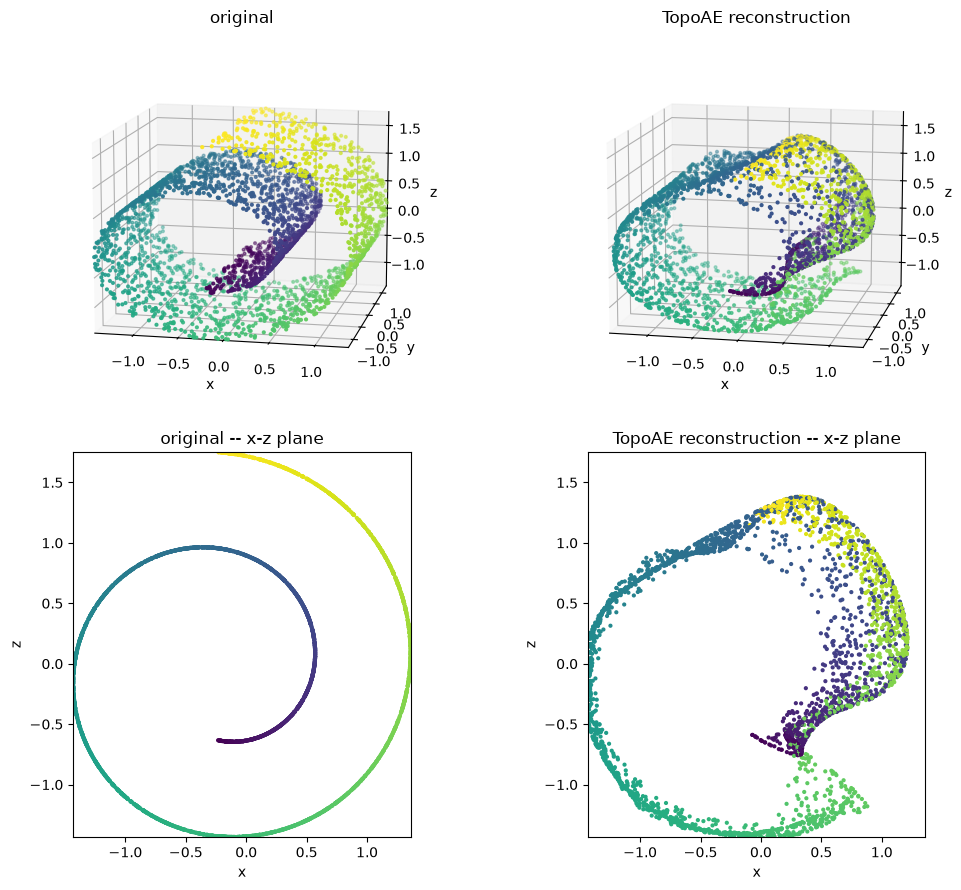

In [4]:
with torch.no_grad():
    y_all = model.decode(model.encode(x_all))
y_all = y_all.numpy()

fig = plt.figure(figsize=(11, 9))
for i, (data, title) in enumerate([(X, "original"), (y_all, "TopoAE reconstruction")]):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t, cmap="viridis", s=4)
    ax.view_init(**VIEW)
    ax.set_title(title)
    ax.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax.set_ylim(X[:, 1].min(), X[:, 1].max())
    ax.set_zlim(X[:, 2].min(), X[:, 2].max())
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

    ax2 = fig.add_subplot(2, 2, i + 3)
    ax2.scatter(data[:, 0], data[:, 2], c=t, cmap="viridis", s=4)
    ax2.set_title(f"{title} -- x-z plane")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
    ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## §5. How faithful is it, in numbers

Held-out reconstruction error, and the matched-baseline comparison `CLAUDE.md` mandates: same
width, depth, and training protocol as the TopoAE, at the same 2-D bottleneck. If the TopoAE is
not clearly better here, the topological term is not buying anything on a manifold it was
designed for — and that is a real result about the model, stated plainly rather than glossed.

In [5]:
with torch.no_grad():
    z_holdout = model.encode(x_holdout)
    y_holdout = model.decode(z_holdout)
    y_plain_holdout = plain(x_holdout)["y"]

topoae_stats = cae.reconstruction_stats(x_holdout.double(), y_holdout.double())
plain_stats = cae.reconstruction_stats(x_holdout.double(), y_plain_holdout.double())
rel_err = float(
    (torch.linalg.vector_norm(x_holdout - y_holdout, dim=-1)
     / torch.linalg.vector_norm(x_holdout, dim=-1)).mean()
)
beats_baseline = topoae_stats["mse_per_dim"] < plain_stats["mse_per_dim"]
ratio = plain_stats["mse_per_dim"] / topoae_stats["mse_per_dim"]

print("=== held-out reconstruction ===")
print(f"TopoAE                    mse_per_dim = {topoae_stats['mse_per_dim']:.6f}")
print(f"plain AE (d={LATENT_DIM})              mse_per_dim = {plain_stats['mse_per_dim']:.6f}")
print(f"TopoAE mean relative error             = {rel_err:.4f}  ({100 * rel_err:.1f}% of point norm)")
print(f"TopoAE / plain-AE mse_per_dim ratio    = {ratio:.3f}  (beats baseline: {beats_baseline})")

=== held-out reconstruction ===
TopoAE                    mse_per_dim = 0.029190
plain AE (d=2)              mse_per_dim = 0.025395
TopoAE mean relative error             = 0.1866  (18.7% of point norm)
TopoAE / plain-AE mse_per_dim ratio    = 0.870  (beats baseline: False)


## §6. Did the topology survive

This model has no charts, so there is no chart-survival analogue. The replacement is the
model's own distinguishing internal state: for each persistence pair the MST selected in the
ambient space, does its length agree with the same pair's length in the latent? Points near the
diagonal mean the pairing that carries the topological loss round-trips faithfully.

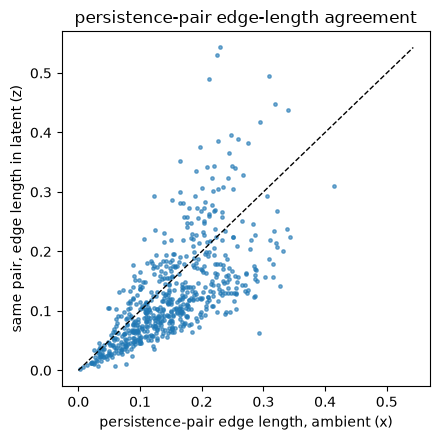

loss_x_to_z = 2.817704   loss_z_to_x = 81.819630
corr(ambient edge length, latent edge length) = 0.6659


In [6]:
with torch.no_grad():
    z_holdout_full = model.encode(x_holdout)

d_x = topoae.pairwise_distances_f64(x_holdout)
z_scaled = z_holdout_full * topoae.latent_unit_scale(z_holdout_full)
d_z = topoae.pairwise_distances_f64(z_scaled)

pairs_x = topoae.persistence_pairs(d_x.numpy())

edge_len_x = d_x[pairs_x[:, 0], pairs_x[:, 1]].numpy()
edge_len_z_at_x_pairs = d_z[pairs_x[:, 0], pairs_x[:, 1]].numpy()

loss = topoae.topological_loss(d_x, d_z)
loss_x_to_z = float(loss["loss_x_to_z"].item())
loss_z_to_x = float(loss["loss_z_to_x"].item())
corr = float(np.corrcoef(edge_len_x, edge_len_z_at_x_pairs)[0, 1])

plt.figure(figsize=(4.5, 4.5))
plt.scatter(edge_len_x, edge_len_z_at_x_pairs, s=6, alpha=0.6)
lims = [0, max(edge_len_x.max(), edge_len_z_at_x_pairs.max())]
plt.plot(lims, lims, "k--", lw=1)
plt.xlabel("persistence-pair edge length, ambient (x)")
plt.ylabel("same pair, edge length in latent (z)")
plt.title("persistence-pair edge-length agreement")
plt.tight_layout()
plt.show()

print(f"loss_x_to_z = {loss_x_to_z:.6f}   loss_z_to_x = {loss_z_to_x:.6f}")
print(f"corr(ambient edge length, latent edge length) = {corr:.4f}")

## §7. Read-out

In [7]:
checks = {
    "relative reconstruction error < 15%": (rel_err < 0.15, f"{100 * rel_err:.1f}%"),
    "beats the matched plain-AE baseline": (beats_baseline, f"{ratio:.2f}x"),
    "persistence-pair edge lengths correlate (r > 0.8)": (corr > 0.8, f"r={corr:.3f}"),
}
for label, (ok, value) in checks.items():
    print(f"{label:48s}: {str(ok):5s}  ({value})")

recovered = all(ok for ok, _ in checks.values())
print(f"\nSwiss roll recovered: {recovered}")
print()
if recovered:
    print(
        "The implementation reconstructs a known 2-dimensional manifold within the stated\n"
        "bound, beats a matched plain-AE baseline at the same 2-D bottleneck, and the\n"
        "persistence pairing that carries the topological loss round-trips from ambient to\n"
        "latent with strong agreement. A FAIL on the PU data would therefore be a statement\n"
        "about that data, not about a broken TopoAE implementation."
    )
else:
    print(
        "The implementation did NOT clearly recover the Swiss roll on every check. Any FAIL\n"
        "on the PU data cannot yet be attributed to the data until this is explained."
    )

relative reconstruction error < 15%             : False  (18.7%)
beats the matched plain-AE baseline             : False  (0.87x)
persistence-pair edge lengths correlate (r > 0.8): False  (r=0.666)

Swiss roll recovered: False

The implementation did NOT clearly recover the Swiss roll on every check. Any FAIL
on the PU data cannot yet be attributed to the data until this is explained.
